In [47]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [48]:
data_path = "tweets-data\sentiment-english.csv"
prepro_data_path = "tweets-data\hasilpreprocess-english.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_3000\1609628049.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-english.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_3000\1609628049.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-english.csv"


In [49]:
data = pd.read_csv(data_path)

In [50]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893708251146912122,Sun Feb 23 17:03:25 +0000 2025,0,Same principle for the proper match going fans...,1893708251146912122,NaN,NaN,en,World,0,0,0,https://x.com/vault_dweller_7/status/189370825...,1102944326894698497,vault_dweller_7
1,1893692674755944672,Sun Feb 23 17:03:03 +0000 2025,0,@UTDchumalo @Ugochukwu_96 What position is Man...,1893708158507380822,NaN,UTDchumalo,en,all over Nigeria,0,0,0,https://x.com/Tchi_no/status/1893708158507380822,3064292589,Tchi_no
2,1893708161367851470,Sun Feb 23 17:03:03 +0000 2025,0,[®]™ MANCHESTER CITY GOAL IS RULED OFFSIDE htt...,1893708161367851470,https://pbs.twimg.com/media/GkfNh2DWMAAwry8.jpg,NaN,en,📧 info@unitedradar.com,0,0,1,https://x.com/UnitedRadar/status/1893708161367...,1548251668424187904,UnitedRadar
3,1893652483743895806,Sun Feb 23 17:03:10 +0000 2025,0,@CollinsZagaa @BashirAhmaad Abeg wrote your mo...,1893708190321168510,NaN,CollinsZagaa,en,NaN,0,0,0,https://x.com/Amarantopashilo/status/189370819...,1528445633606127616,Amarantopashilo
4,1893708098155467238,Sun Feb 23 17:02:48 +0000 2025,0,Access Bank Manchester United I made the wrong...,1893708098155467238,NaN,NaN,en,NaN,0,0,0,https://x.com/agbulight/status/189370809815546...,1597205847649796098,agbulight


In [51]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,Same principle for the proper match going fans...,vault_dweller_7,Sun Feb 23 17:03:25 +0000 2025
1,@UTDchumalo @Ugochukwu_96 What position is Man...,Tchi_no,Sun Feb 23 17:03:03 +0000 2025
2,[®]™ MANCHESTER CITY GOAL IS RULED OFFSIDE htt...,UnitedRadar,Sun Feb 23 17:03:03 +0000 2025
3,@CollinsZagaa @BashirAhmaad Abeg wrote your mo...,Amarantopashilo,Sun Feb 23 17:03:10 +0000 2025
4,Access Bank Manchester United I made the wrong...,agbulight,Sun Feb 23 17:02:48 +0000 2025
...,...,...,...
999,@Mammabell15 Love this ️,Manchester96622,Sun Feb 23 12:35:22 +0000 2025
1000,@colinmufc2 I know it's harsh but Manchester U...,17cosmas,Sun Feb 23 12:35:12 +0000 2025
1001,Even when he was in Manchester United his divi...,alolaDade_Owo,Sun Feb 23 12:34:56 +0000 2025
1002,@Lea_EFC Manchester United s man of the match*...,Enzo__Benitez_,Sun Feb 23 12:34:40 +0000 2025


# 1. Cleaning Data

In [52]:
df.shape

(1004, 3)

In [53]:
df = df.drop_duplicates(subset=['full_text'])

In [54]:
df.duplicated().sum()

0

In [55]:
df = df.dropna()

In [56]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [57]:
df.shape

(983, 3)

In [58]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [59]:
df['full_text'] = df['full_text'].str.lower()

In [60]:
df

,full_text,username,created_at
0,same principle for the proper match going fans...,vault_dweller_7,Sun Feb 23 17:03:25 +0000 2025
1,what position is manchester united currently,Tchi_no,Sun Feb 23 17:03:03 +0000 2025
2,manchester city goal is ruled offside,UnitedRadar,Sun Feb 23 17:03:03 +0000 2025
3,abeg wrote your mother fucker full oo make e n...,Amarantopashilo,Sun Feb 23 17:03:10 +0000 2025
4,access bank manchester united i made the wrong...,agbulight,Sun Feb 23 17:02:48 +0000 2025
...,...,...,...
999,love this,Manchester96622,Sun Feb 23 12:35:22 +0000 2025
1000,i know its harsh but manchester united cant pl...,17cosmas,Sun Feb 23 12:35:12 +0000 2025
1001,even when he was in manchester united his divi...,alolaDade_Owo,Sun Feb 23 12:34:56 +0000 2025
1002,manchester united s man of the match,Enzo__Benitez_,Sun Feb 23 12:34:40 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [61]:
# Normalisasi

norm = {
    " u ": " you ", " r ": " are ", " ur ": " your ", " pls ": " please ",
    " msg ": " message ", " btw ": " by the way ", " idk ": " I don't know ", " thx ": " thanks ",
    " omg ": " oh my god ", " lol ": " laugh out loud ", " brb ": " be right back ", " gtg ": " got to go ",
    " dm ": " direct message ", " wtf ": " what the heck "
}

def normalisasi(str_text):
    for i in norm:
        str_text = str_text.replace(i, norm[i])
    return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,same principle for the proper match going fans...,vault_dweller_7,Sun Feb 23 17:03:25 +0000 2025
1,what position is manchester united currently,Tchi_no,Sun Feb 23 17:03:03 +0000 2025
2,manchester city goal is ruled offside,UnitedRadar,Sun Feb 23 17:03:03 +0000 2025
3,abeg wrote your mother fucker full oo make e n...,Amarantopashilo,Sun Feb 23 17:03:10 +0000 2025
4,access bank manchester united i made the wrong...,agbulight,Sun Feb 23 17:02:48 +0000 2025
...,...,...,...
999,love this,Manchester96622,Sun Feb 23 12:35:22 +0000 2025
1000,i know its harsh but manchester united cant pl...,17cosmas,Sun Feb 23 12:35:12 +0000 2025
1001,even when he was in manchester united his divi...,alolaDade_Owo,Sun Feb 23 12:34:56 +0000 2025
1002,manchester united s man of the match,Enzo__Benitez_,Sun Feb 23 12:34:40 +0000 2025


In [62]:
# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

manual_stop_words = [
    "the", "to", "a", "and", "is", "in", "for", "of", "you", "are", "he", "i", "it", "with", "at", "that",
    "this", "on", "we", "be", "not", "like", "as", "has", "have", "all", "but", "can", "if", "his", "one",
    "united", "manchester", "liverpool", "club", "city", "league", "goals", "fans", "arsenal", "vs", "against",
    "t", "s", "https", "co", "2", "was", "were", "so", "or", "do", "does", "did", "about", "from", "by", "an", "there"
]

nltk_stop_words = set(stopwords.words('english'))
custom_stop_words = nltk_stop_words.union(set(manual_stop_words))

def remove_stopwords_manual(str_text):
    words = str_text.split()
    filtered_words = [word for word in words if word.lower() not in manual_stop_words]
    return " ".join(filtered_words)

df['full_text'] = df['full_text'].apply(remove_stopwords_manual)

df[['full_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,same principle proper match going crowd who th...
1,what position currently
2,goal ruled offside
3,abeg wrote your mother fucker full oo make e n...
4,access bank made wrong life choices man
...,...
999,love
1000,know its harsh cant play 6 defenders pitch off...
1001,even when diving acts disgust me lot most reas...
1002,man match


In [63]:
# Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0       [same, principle, proper, match, going, crowd,...
1                             [what, position, currently]
2                                  [goal, ruled, offside]
3       [abeg, wrote, your, mother, fucker, full, oo, ...
4         [access, bank, made, wrong, life, choices, man]
                              ...                        
999                                                [love]
1000    [know, its, harsh, cant, play, 6, defenders, p...
1001    [even, when, diving, acts, disgust, me, lot, m...
1002                                         [man, match]
1003                                                [rep]
Name: full_text, Length: 983, dtype: object

In [64]:
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['full_text'] = df['full_text'].apply(stemming)
tokenized.to_csv(prepro_data_path, index=False)
data = pd.read_csv(prepro_data_path, encoding='latin1')


# 3. Labeling

In [65]:
data

,full_text
0,"['same', 'principle', 'proper', 'match', 'goin..."
1,"['what', 'position', 'currently']"
2,"['goal', 'ruled', 'offside']"
3,"['abeg', 'wrote', 'your', 'mother', 'fucker', ..."
4,"['access', 'bank', 'made', 'wrong', 'life', 'c..."
...,...
978,['love']
979,"['know', 'its', 'harsh', 'cant', 'play', '6', ..."
980,"['even', 'when', 'diving', 'acts', 'disgust', ..."
981,"['man', 'match']"


In [66]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [67]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 389
Netral = 436
Negatif = 158

Total Data : 983


In [68]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['same', 'principle', 'proper', 'match', 'goin...",Positif
1,"['what', 'position', 'currently']",Netral
2,"['goal', 'ruled', 'offside']",Netral
3,"['abeg', 'wrote', 'your', 'mother', 'fucker', ...",Positif
4,"['access', 'bank', 'made', 'wrong', 'life', 'c...",Negatif
...,...,...
978,['love'],Positif
979,"['know', 'its', 'harsh', 'cant', 'play', '6', ...",Negatif
980,"['even', 'when', 'diving', 'acts', 'disgust', ...",Positif
981,"['man', 'match']",Netral


# 4. Visualisasi

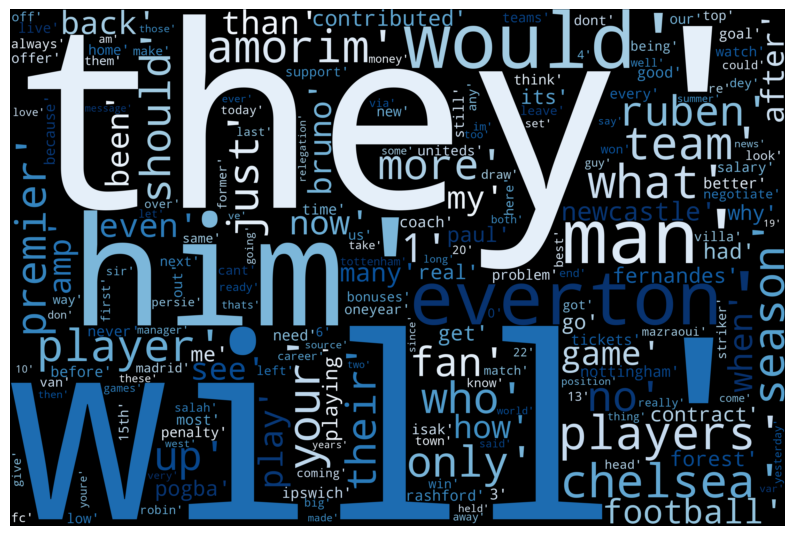

In [69]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

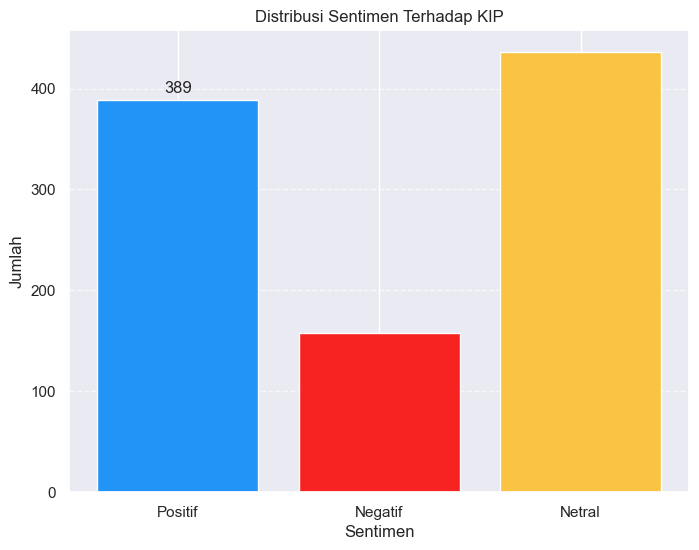

In [70]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Multinomial Naive Bayes

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [72]:
data.head()

,full_text,klasifikasi
0,"['same', 'principle', 'proper', 'match', 'goin...",Positif
1,"['what', 'position', 'currently']",Netral
2,"['goal', 'ruled', 'offside']",Netral
3,"['abeg', 'wrote', 'your', 'mother', 'fucker', ...",Positif
4,"['access', 'bank', 'made', 'wrong', 'life', 'c...",Negatif


In [73]:
data.shape

(983, 2)

In [74]:
data.klasifikasi.unique()

array(['Positif', 'Netral', 'Negatif'], dtype=object)

In [75]:
data.klasifikasi.value_counts()

klasifikasi
Netral     436
Positif    389
Negatif    158
Name: count, dtype: int64

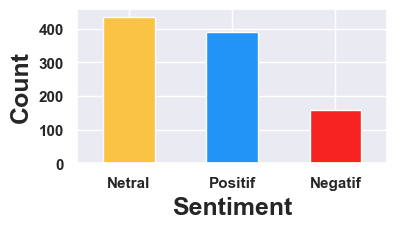

In [76]:
data.klasifikasi.value_counts().plot(kind='bar', figsize=(4, 2), rot=0, color=['#fac343', '#2394f7', '#f72323'])
plt.xlabel('Sentiment', fontweight='bold', fontsize=18)
plt.ylabel('Count', fontweight='bold', fontsize=18)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold');

In [77]:
labelencoder = LabelEncoder()
data['Target'] = labelencoder.fit_transform(data['klasifikasi'])

In [78]:
data.Target.unique()

array([2, 1, 0])

In [79]:
X = data.full_text
y = data.Target

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [81]:
len(X_train), len(X_test), len(y_train), len(y_test)

(786, 197, 786, 197)

In [82]:
clf = Pipeline([
    ('cv', CountVectorizer()),
    ('mnb', MultinomialNB(force_alpha=False))
])

In [83]:
clf.fit(X_train, y_train)

Pipeline(steps=[('cv', CountVectorizer()),
                ('mnb', MultinomialNB(force_alpha=False))])

In [84]:
print('Accuracy on the test set:', round(clf.score(X_test, y_test), 4))

Accuracy on the test set: 0.6091


In [85]:
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

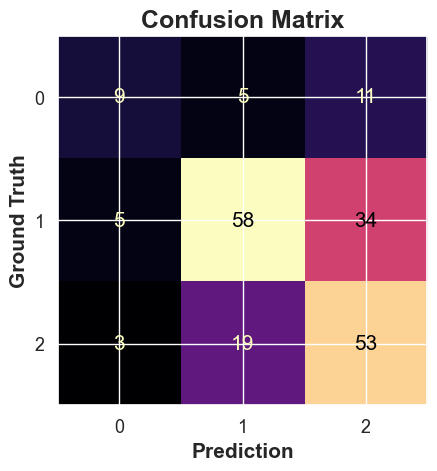

In [86]:

disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [87]:
cat_labels = ['negative', 'neutral', 'positive']
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=cat_labels)

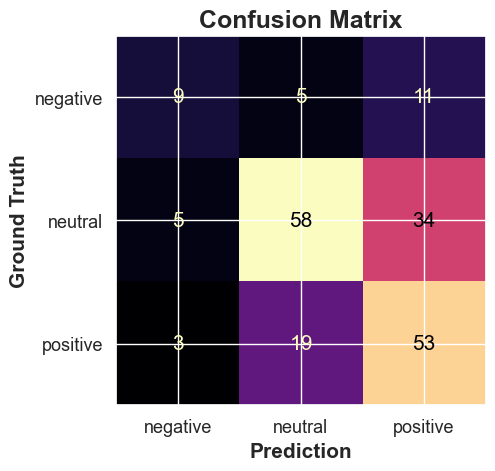

In [88]:
disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [89]:
print('F1 score:', round(metrics.f1_score(y_test, y_pred, average='micro'), 4))

F1 score: 0.6091


In [90]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.36      0.43        25
           1       0.71      0.60      0.65        97
           2       0.54      0.71      0.61        75

    accuracy                           0.61       197
   macro avg       0.59      0.55      0.56       197
weighted avg       0.62      0.61      0.61       197



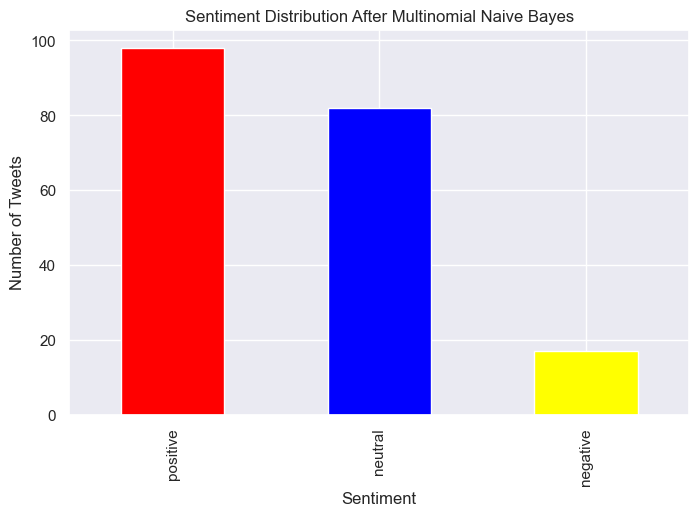

In [91]:
df_result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_result['Predicted'] = df_result['Predicted'].map(label_mapping)

sentiment_count = df_result['Predicted'].value_counts()

plt.figure(figsize=(8,5))
sentiment_count.plot(kind='bar', color=['red', 'blue', 'yellow'])
plt.title('Sentiment Distribution After Multinomial Naive Bayes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()